In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lab 6 - Fisher's Linear Discriminant and Logistic Regression
- For equations, refer to Bishop's book, Section 4.1.4 and the slides

# Part I - Fisher's Linear Discriminant for Binary Classification (2 classes)

## Data Generation and Visualisation
- First we'll use scikit-learn to generate 2 blobs of data in 2D, using the [make_blobs()](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) function.
- The data consists of 600 points divided into 2 classes, 0 and 1.

In [25]:
from sklearn.datasets import make_blobs

In [26]:
X, y = make_blobs(n_samples=600, centers=2, n_features=2, random_state=0)

In [27]:
x0 = X[y == 1]
x1 = X[y == 0]

Let's confirm the data has two classes

In [28]:
np.unique(y)

array([0, 1])

## Exercise 1
- Now create a scatter plot to visualise the generated data. 
- Make sure to paint each point based on the class they belong to, as shown in the Figure below.

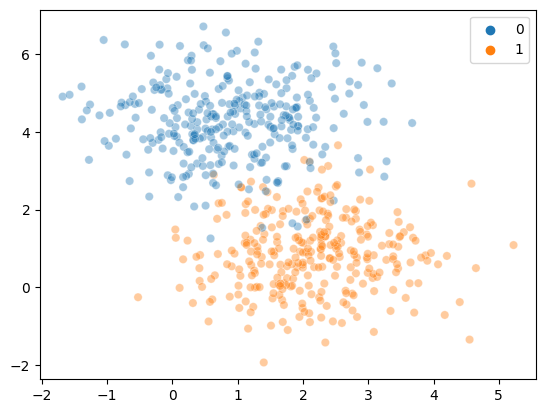

In [8]:
# your code goes here:


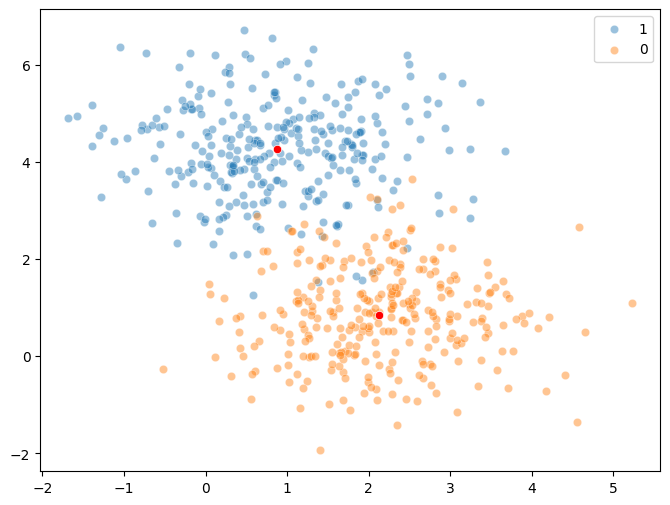

In [29]:
fig = plt.figure(figsize= (8,6))
sns.scatterplot(x = x1[:,0], y= x1[:,1], label= "1", alpha =0.45)
sns.scatterplot(x = x0[:,0], y= x0[:,1], label= "0", alpha =0.45)

m1 = np.array([x1[:,0].mean() , x1[:,1].mean()])
m0 = np.array([x0[:,0].mean() , x0[:,1].mean()])

sns.scatterplot(x = [m1[0]], y= [m1[1]], color = "red", marker= "o")
sns.scatterplot(x = [m0[0]], y= [m0[1]], color = "red", marker= "o")
plt.legend()


## Exercise 2
* Now plot a histogram of the data projected on each of the 2 dimensions of $X$ ($0$ and $1$)

As an example, below is a figure that shows the projection on dimension $1$.

_Tips:_ 
* You can either use `histplot()` to generate the plot, in which case it might be easier to pack $X$ and $y$ into a pandas DataFrame.
* Alternatively, considering that you will generate this plot many times throughout this lab, you can write a function that takes the projected vector and the class labels.
* Use 30 bins to obtain a similar plot.

In [30]:
def make_hist(vector, label):
    plt.figure(figsize= (8,6))
    sns.histplot(x= vector, hue= label, bins= 30)
    plt.legend(title = "class", labels= ["0", "1"])

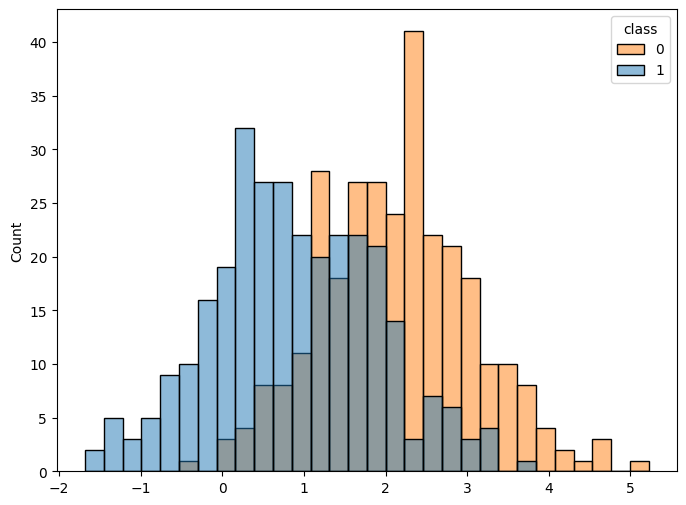

In [31]:
make_hist(X[:,0], y)

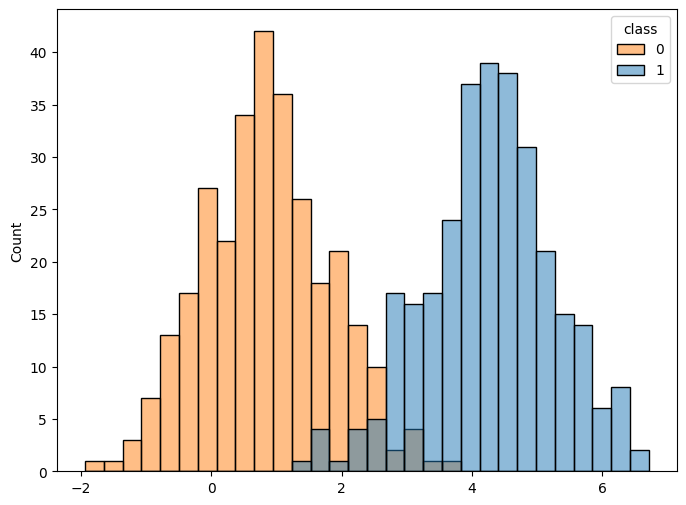

In [32]:
make_hist(X[:,1], y)

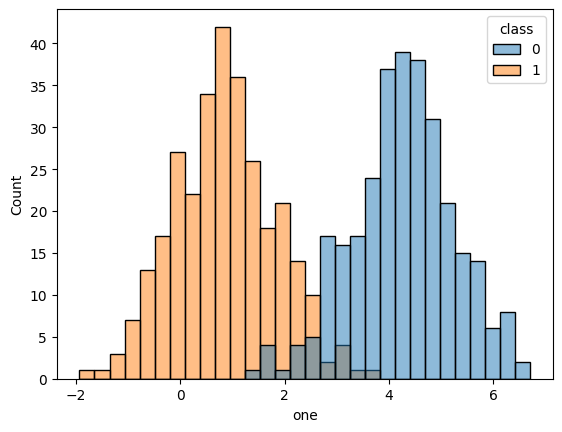

In [26]:
# your code goes here


## Exercise 3 - Implement Fisher's linear discriminant

* Use numpy to calculate $\vec{w}$.
* Plot the data (as you did in Exercise 1), and add a line on the direction of $\vec{w}$ (reference Figure below).
* Project the points onto the calculated vector, and plot the projection (as you did in Exercise 2) (reference Figure below).

In [33]:
def cov_matrix(x):
    m = x.mean(axis= 0)
    cov_m =  np.zeros((x.shape[1], x.shape[1]))
    
    for i in range(x.shape[0]):
        xn = (x[i]-m).reshape(-1,1)
        cov_m = cov_m + xn @ xn.T
        
    return cov_m

In [34]:
Sw = cov_matrix(x0) + cov_matrix(x1)
print(Sw)

[[567.71356713   2.77470709]
 [  2.77470709 573.46443367]]


In [35]:
w = np.linalg.inv(Sw)@(m1-m0)
w = w/np.linalg.norm(w)


In [36]:
x_ = np.linspace(-1000,500,200)

In [37]:
reta = np.outer(x_, w)
reta

array([[ 3.50869460e+02, -9.36424382e+02],
       [ 3.48224715e+02, -9.29365906e+02],
       [ 3.45579970e+02, -9.22307431e+02],
       [ 3.42935226e+02, -9.15248956e+02],
       [ 3.40290481e+02, -9.08190481e+02],
       [ 3.37645736e+02, -9.01132005e+02],
       [ 3.35000992e+02, -8.94073530e+02],
       [ 3.32356247e+02, -8.87015055e+02],
       [ 3.29711502e+02, -8.79956580e+02],
       [ 3.27066758e+02, -8.72898104e+02],
       [ 3.24422013e+02, -8.65839629e+02],
       [ 3.21777268e+02, -8.58781154e+02],
       [ 3.19132524e+02, -8.51722679e+02],
       [ 3.16487779e+02, -8.44664203e+02],
       [ 3.13843034e+02, -8.37605728e+02],
       [ 3.11198290e+02, -8.30547253e+02],
       [ 3.08553545e+02, -8.23488778e+02],
       [ 3.05908800e+02, -8.16430302e+02],
       [ 3.03264056e+02, -8.09371827e+02],
       [ 3.00619311e+02, -8.02313352e+02],
       [ 2.97974566e+02, -7.95254877e+02],
       [ 2.95329822e+02, -7.88196402e+02],
       [ 2.92685077e+02, -7.81137926e+02],
       [ 2.

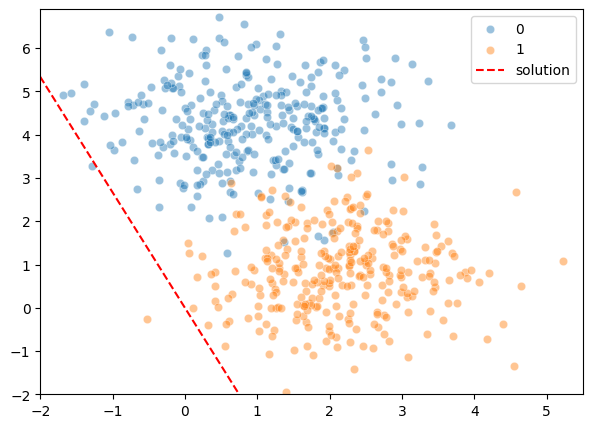

In [38]:
fig = plt.figure(figsize= (7,5))
sns.scatterplot(x = x1[:,0], y= x1[:,1], label= "0", alpha =0.45)
sns.scatterplot(x = x0[:,0], y= x0[:,1], label= "1", alpha =0.45)

m1 = np.array([x1[:,0].mean() , x1[:,1].mean()])
m0 = np.array([x0[:,0].mean() , x0[:,1].mean()])

sns.lineplot(x = reta[:,0], y= reta[:,1], color = "red", linestyle= "--", label= "solution")
plt.ylim(-2,6.9)
plt.xlim(-2,5.5)
plt.legend()


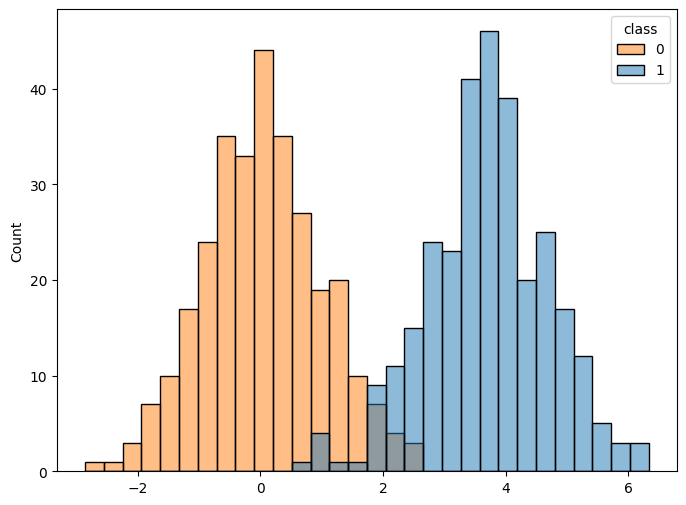

In [39]:
proj = X @ w

make_hist(proj, y)

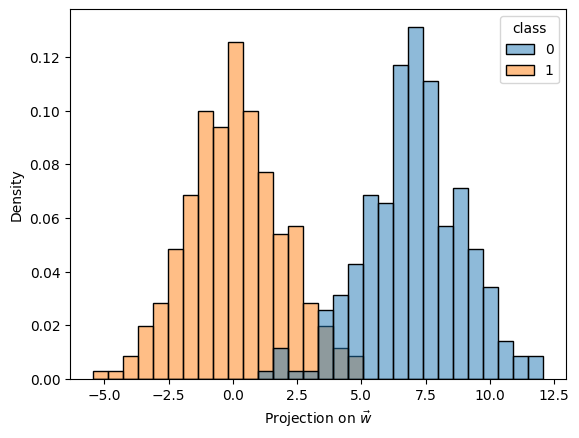

In [58]:
# your code goes here:


## Exercise 4

* In this exercise you will use the `RidgeClassifier` from sklearn (as shown below) to obtain the class predictions from different types of projections:
    * component 0 of the data
    * component 1 of the data
    * the calculated vector $\vec{w}$
    
* Calculate the accuracy of these predictions using `accuracy_score` from sklearn.

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import RidgeClassifier

In [ ]:
# Follow this structure for each projection:
r = RidgeClassifier()
r.fit(projection, y)
predicted_y = r.predict(projection)
accuracy = accuracy_score(predicted_y, y)

In [67]:
r = RidgeClassifier()
X0 = X[:,0].reshape(-1,1)
r.fit(X0, y)
predicted_y = r.predict(X0)
accuracy_0 = accuracy_score(predicted_y, y)

In [65]:
r = RidgeClassifier()
X1 = X[:,1].reshape(-1,1)
r.fit(X1, y)
predicted_y = r.predict(X1)
accuracy_1 = accuracy_score(predicted_y, y)

In [69]:
r = RidgeClassifier()
Xw = proj.reshape(-1,1)
r.fit(Xw, y)
predicted_y = r.predict(Xw)
accuracy = accuracy_score(predicted_y, y)

In [71]:
print(f"projection: first dimension, accuracy = {accuracy_0}")
print(f"projection: second dimension, accuracy = {accuracy_1}")
print(f"projection: Fisher's linear discriminant, accuracy = {accuracy}")

projection: first dimension, accuracy = 0.7366666666666667
projection: second dimension, accuracy = 0.955
projection: Fisher's linear discriminant, accuracy = 0.965


In [ ]:
# your code goes here:


projection: first dimension, accuracy = 0.7366666666666667
projection: second dimension, accuracy = 0.955
projection: Fisher's linear discriminant, accuracy = 0.965


# Part II - Generalised Linear Discriminant (multi-class)

**NOTE:** For this part you will be using a multi-class estimator from scikit-learn (read the [documentation](https://scikit-learn.org/stable/modules/lda_qda.html#lda-qda)).

## Exercise 1 - Generate data

* Generate a 3 classes dataset in 2D, with the same rules as before (make 300 points per class)
* Plot the data and then similar histograms (on each dimension) as Part I Exercises 1 and 2.

In [127]:
X, y = make_blobs(n_samples=600, centers=3, n_features=2, random_state=0)

In [128]:
X

array([[-0.31658683,  4.5708382 ],
       [ 1.64265316,  3.84306754],
       [ 0.8433895 ,  4.00599645],
       ...,
       [ 2.40704763,  1.27689919],
       [-2.15246105,  3.91001909],
       [ 1.90811845,  4.64375231]], shape=(600, 2))

In [85]:
np.unique(y)

array([0, 1, 2])

<Axes: >

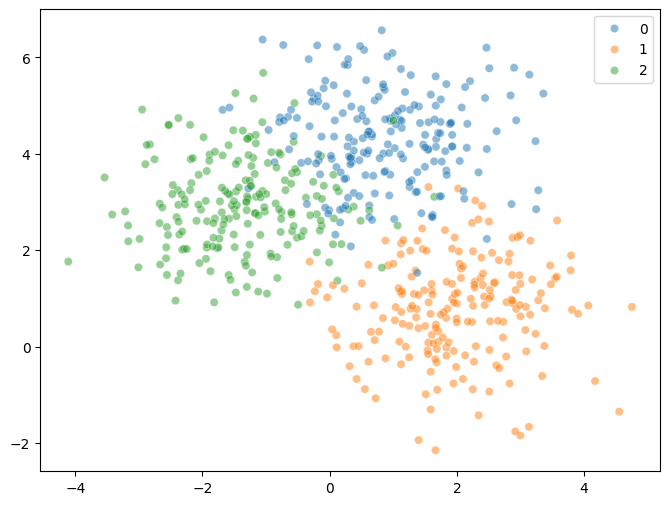

In [129]:
fig = plt.figure(figsize=(8,6))
sns.scatterplot(x= X[:,0], y= X[:,1], hue= y, palette= "tab10", alpha= 0.5)

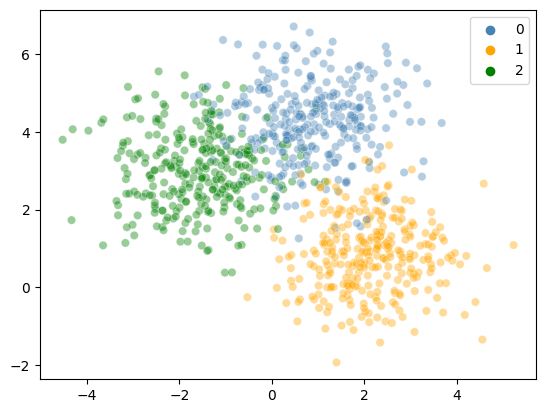

In [ ]:
# your code goes here: 



In [130]:
def make_hist(vector, label):
    plt.figure(figsize= (8,6))
    sns.histplot(x= vector, hue= label, bins= 30)
    # plt.legend(title = "class", labels= ["2", "1", "0"])

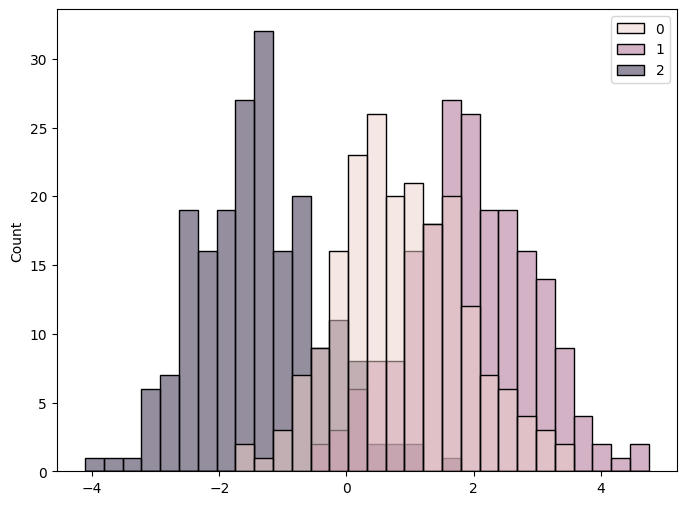

In [131]:
make_hist(X[:,0], y)

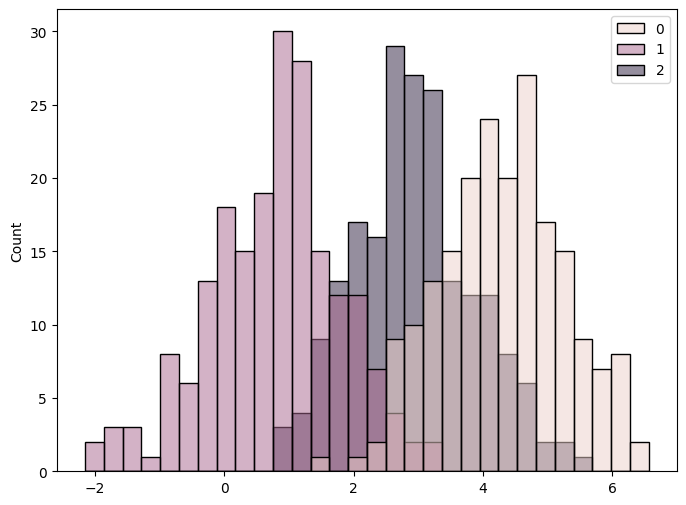

In [132]:
make_hist(X[:,1], y)

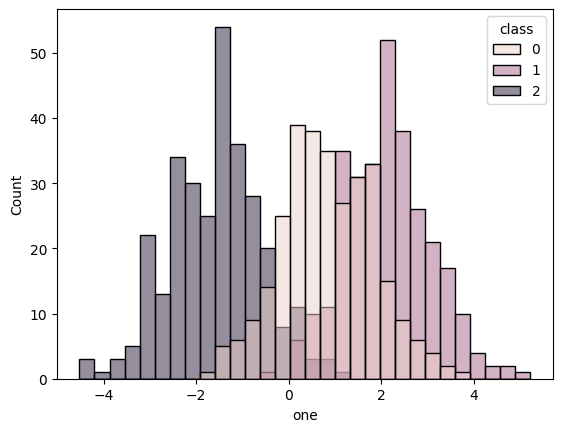

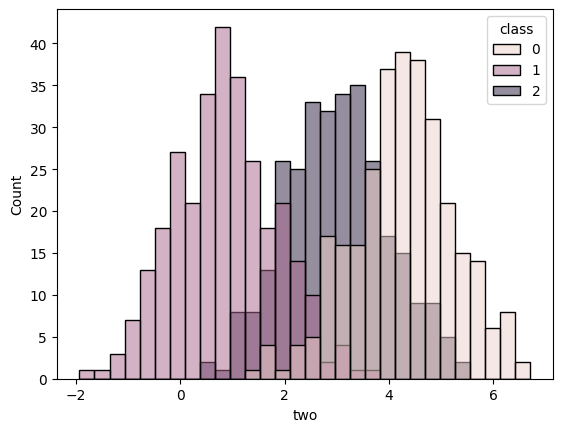

In [74]:
# your code goes here:


## Exercise 2 - Linear Discriminant Analysis

* Use sklearn's implementation of LDA to project the points in a single dimension and then plot the projected data

In [98]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Remember that since we want to project our data onto a vector, the parameter n_components of `LinearDiscriminantAnalysis` should be set to 1

In [133]:
lda = LinearDiscriminantAnalysis(n_components= 1)
lda.fit(X,y)
predicted_y = lda.predict(X)
proj_sklearn = lda.transform(X)

In [134]:
proj_sklearn = proj_sklearn.flatten()
proj_sklearn

array([ 1.98786968,  0.0603455 ,  0.74637782, -2.31966533, -2.27381221,
        0.09598616,  0.44409983,  0.9711751 , -2.9423506 ,  1.85088216,
       -2.25850121,  2.44848241,  2.56329007,  2.12173935, -3.79570229,
        0.38545931,  1.23506782,  0.26647432, -2.56982522, -2.22986697,
       -0.19693573, -5.15259938,  1.85522931,  1.1714183 ,  0.30830503,
        0.60785059,  1.86266145, -1.97116709,  1.05483935,  0.4788386 ,
        0.60124689,  3.19443651,  0.46259203,  1.50567353,  3.46580226,
        2.56712612,  0.15698686, -3.57073303, -3.60130796, -2.70658693,
        2.41477725,  1.1292925 ,  0.51139807,  1.12440364, -1.64302928,
        2.37250405,  0.93892548,  2.35601461,  0.3084931 , -0.33244186,
        1.13260885, -1.99673526,  2.45994872, -3.87215166, -1.00541409,
        1.07745567,  0.4495356 ,  0.7031173 , -1.48239312, -0.62834215,
        1.25702089, -0.75432316,  1.13746484,  1.78939463,  1.24465576,
        0.83870299,  1.81502714,  1.43449435, -2.37504861, -1.42

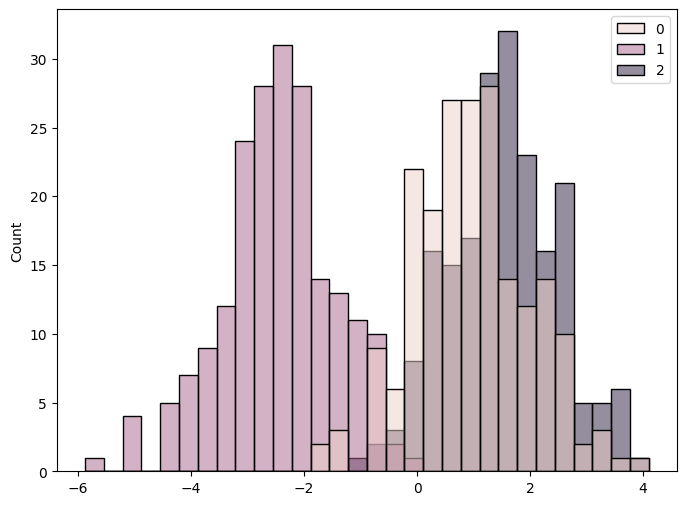

In [135]:
make_hist(proj_sklearn, y)

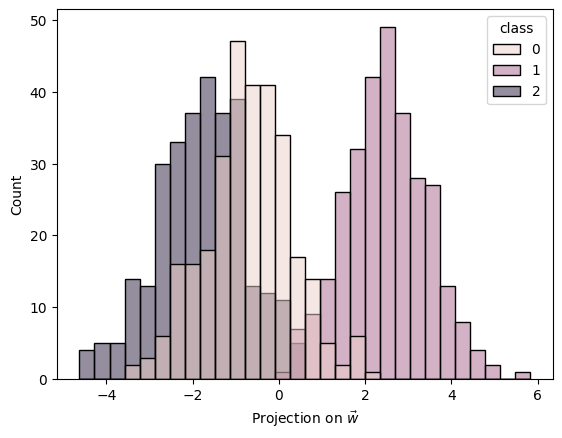

In [76]:
# your code goes here: 


## Exercise 3 - Calculate test set accuracy

* use the default parameters for the LDA classifier, and report the prediction accuracy on a train/test split of 70/30% (use `random_state=0`)
* report also the accuracy of the `RidgeClassfier` you used in Part I 

In [32]:
from sklearn.model_selection import train_test_split

In [12]:
# your code goes here:


Test Accuracies:
LDA classifier: 0.937037037037037
Ridge Classifier fitting: 0.9259259259259259
